# Load and create dataset for HW2:Q1 data

remove particle positions as it is not needed in this task

In [12]:
import pickle as pkl
from torchvision.transforms import Compose, PILToTensor, Resize, ToTensor
import numpy as np
import torch

# image_trans = Compose([Resize((28, 28)), ToTensor()])

data = pkl.load(open('simple_particle_dataset.pkl', 'rb'))


# image_trans = Compose([PILToTensor(), Resize((28, 28))])
# print(data.keys())

images = [img.astype(np.float32) for img in data["images"]]
images = list(map(ToTensor(), images))
# images = list(map(Resize((28, 28)), images))

# images = list(map(image_trans(), data["images"]))

labels = [torch.tensor(label[0]).float().unsqueeze(-1) for label in data["labels"]]


dataset = list(zip(images, labels))
# dataset = list(zip(list(map(ToTensor(), images)), list(map(lambda x: torch.tensor(x[0]).float().unsqueeze(-1), data["labels"]))))
# dataset = list(zip(data["images"], list(map(lambda x: x[0], data["labels"]))))
# dataset = [(img.reshape(64, 64), label) for img, label in dataset]

# print(dataset[0][0][0][0].dtype)
# print(len(dataset))
# print(dataset.shape)
# print(dataset[0].shape)
print(dataset[0][0].shape)
print(dataset[0][1].shape)


torch.Size([1, 64, 64])
torch.Size([1])


### Visualizing the Blood Smears

Implement a function to plot some examples of blood smears ...

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_blood_smears(dataset, parasitized):
    """Plot blood smears."""
    fig, axs = plt.subplots(3, 6, figsize=(16, 8))
    for ax in axs.ravel():
        image, label = dataset[np.random.randint(0, len(dataset))]
        if isinstance(image, torch.Tensor):
            image, label = image.numpy().transpose(1, 2, 0), label.numpy()
        ax.imshow(image)
        ax.set_title(f"Parasitized ({label})" if label == parasitized
                     else f"Uninfected ({label})", fontsize=16)
    plt.tight_layout()
    plt.show()

... and use it to plot them.

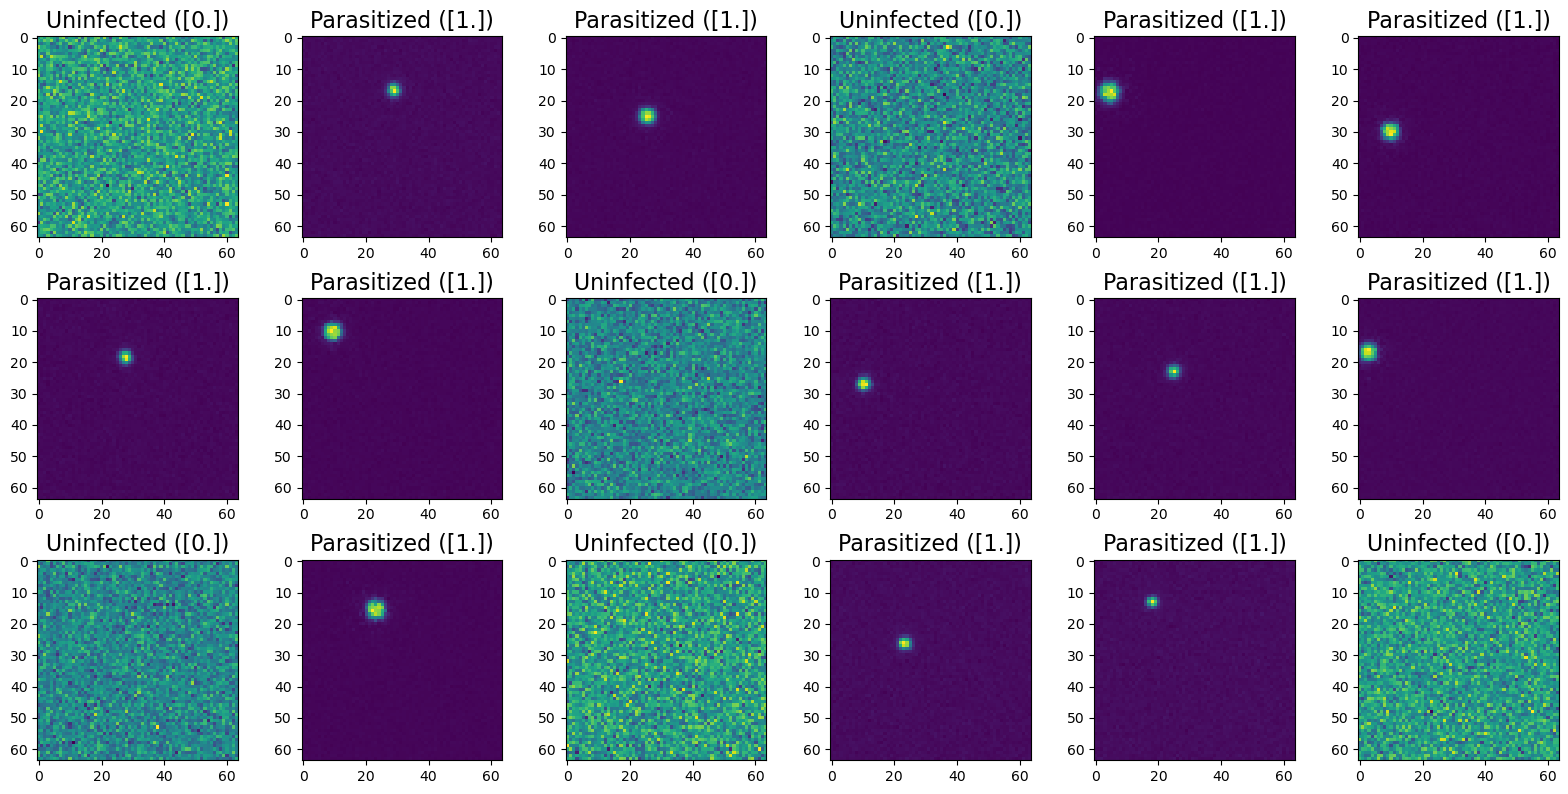

In [14]:
plot_blood_smears(dataset, parasitized=1)

### Splitting the Dataset and Defining the Data Loaders

Split the dataset, composed by ca. 27,000 cell images, into train (80%) and test (20%) sets ...

In [15]:
train, val, test = torch.utils.data.random_split(dataset, [0.7, 0.1, 0.2])

... and define the data loaders.

In [16]:
train_loader = torch.utils.data.DataLoader(train, batch_size=20, shuffle=True)
val_loader = torch.utils.data.DataLoader(val, batch_size=50, shuffle=False)
test_loader = torch.utils.data.DataLoader(test, batch_size=50, shuffle=False)


In [17]:
import torchmetrics as tm

def plot_roc(classifier, loader):
    """Plot ROC curve."""
    roc = tm.ROC(task="binary")
    for image, label in loader:
        roc.update(classifier(image), label.long())

    fig, ax = roc.plot(score=True)
    ax.grid(False)
    ax.axis("square")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="center right")
    plt.show()

## Classifying the Blood Smears with Convolutional Neural Networks

Implement a convolutional neural network with a dense top ...

In [18]:
import deeplay as dl

conv_base = dl.ConvolutionalNeuralNetwork(
    in_channels=1, hidden_channels=[4], out_channels=4,
)
conv_base.blocks[0].pool.configure(torch.nn.MaxPool2d, kernel_size=2)
conv_base.blocks[0].layer.configure(torch.nn.Conv2d, kernel_size=3, padding=1, stride=1)

connector = dl.Layer(torch.nn.AdaptiveAvgPool2d, output_size=1)

dense_top = dl.MultiLayerPerceptron(
    in_features=4, hidden_features=[], out_features=1,
    out_activation=torch.nn.Sigmoid
)
dense_top.blocks[0].layer.configure(bias=False)

cnn = dl.Sequential(conv_base, connector, dense_top)

cnn_classifier = dl.BinaryClassifier(
    model=cnn, optimizer=dl.RMSprop(lr=0.001),
).create()

# print(cnn)
# print(cnn_classifier)

### Training the Convolutional Neural Network

In [19]:
cnn_trainer = dl.Trainer(max_epochs=4, accelerator="auto")
cnn_trainer.fit(cnn_classifier, train_loader, val_loader)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ BCELoss          │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ Sequential       │    192 │ train │     0 │
│ 5 │ optimizer     │ RMSprop          │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 192                                                                                              
Non-trainable params: 0                                                                                            
Total params: 192                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 24                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 3: 100%|██████████| 350/350 [00:01<00:00, 210.25it/s, v_num=133, train_loss_step=5.48e-6, trainBinaryAccuracy_step=1.000, val_loss_step=6.81e-6, valBinaryAccuracy_step=1.000, val_loss_epoch=6.43e-6, valBinaryAccuracy_epoch=1.000, train_loss_epoch=1.94e-5, trainBinaryAccuracy_epoch=1.000]  


(<Figure size 1500x500 with 2 Axes>,
 array([<Axes: title={'center': 'Loss'}, xlabel='Step'>,
        <Axes: title={'center': 'Binaryaccuracy'}, xlabel='Step'>],
       dtype=object))

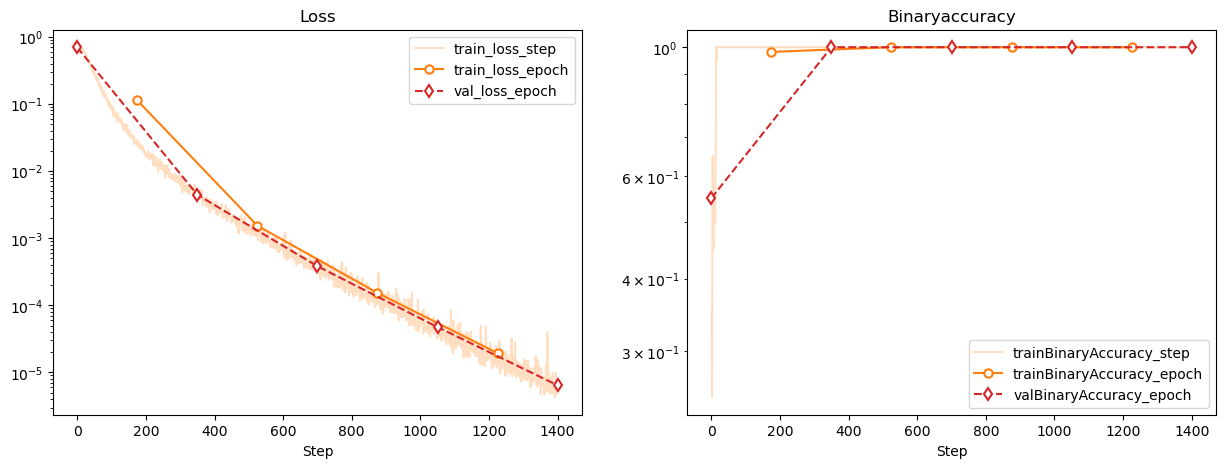

In [20]:
cnn_trainer.history.plot()

### Testing the Convolutional Neural Network

In [21]:
cnn_trainer.test(cnn_classifier, test_loader)

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 40/40 [00:00<00:00, 278.15it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testBinaryAccuracy_epoch  │            1.0            │
│      test_loss_epoch      │   6.033017598383594e-06   │
└───────────────────────────┴───────────────────────────┘

[{'test_loss_epoch': 6.033017598383594e-06, 'testBinaryAccuracy_epoch': 1.0}]

In [22]:
f1 = tm.F1Score(task="binary")

for image, label in test_loader:
    preds = cnn_classifier(image)
    f1.update(preds, label.long())

print(f"F1 score: {f1.compute().item():.4f}")

F1 score: 1.0000


### Plotting the ROC Curve

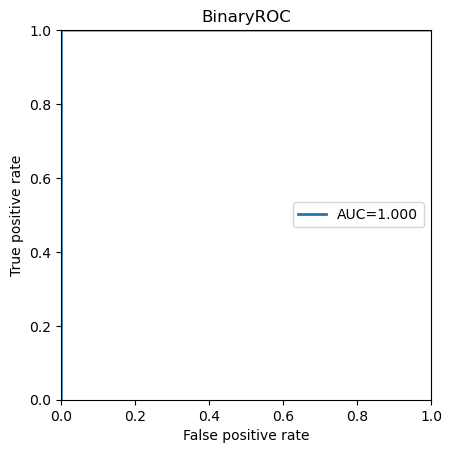

In [23]:
plot_roc(cnn_classifier, test_loader)